<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Decision-Tree/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install gdown
!pip install gdown -q

import gdown

# -------- First file --------
file_id_1 = '1ZdEey7Gsxn05VXdelcf48AjoRTOMqcK_'
gdown.download(f'https://drive.google.com/uc?id={file_id_1}', 'Road_Accident_Data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZdEey7Gsxn05VXdelcf48AjoRTOMqcK_
To: /content/Road_Accident_Data.csv
100%|██████████| 68.7M/68.7M [00:02<00:00, 32.6MB/s]


'Road_Accident_Data.csv'

In [3]:
# To Check Data Was Succefully Downloaded.
import pandas as pd

# Load the CSV file
df = pd.read_csv("Road_Accident_Data.csv")

# Display the first 5 rows
print(df.head())


  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [4]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

df = pd.read_csv('Road_Accident_Data.csv')
print(df.shape)           # (307973, 21)
print(df.dtypes)          # shows column types
print(df.isnull().sum())  # shows missing values per column
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

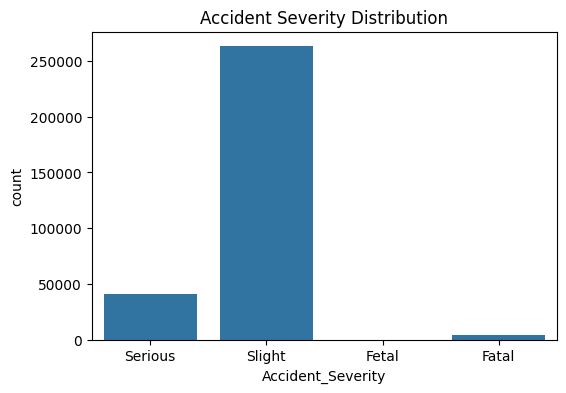

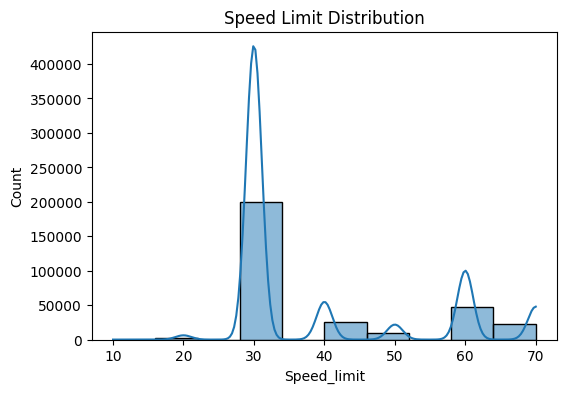

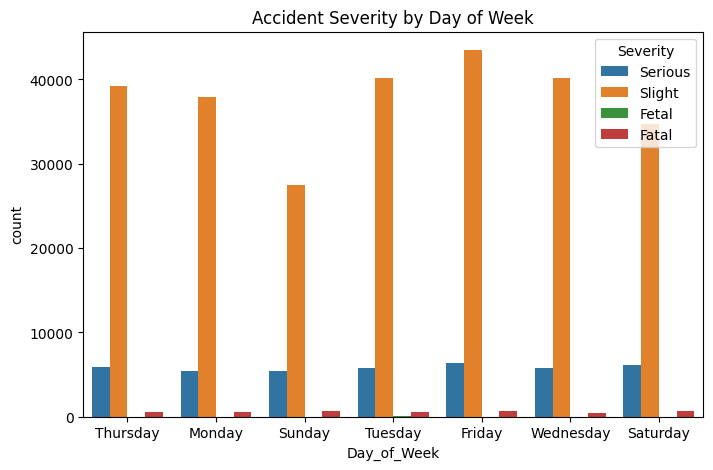

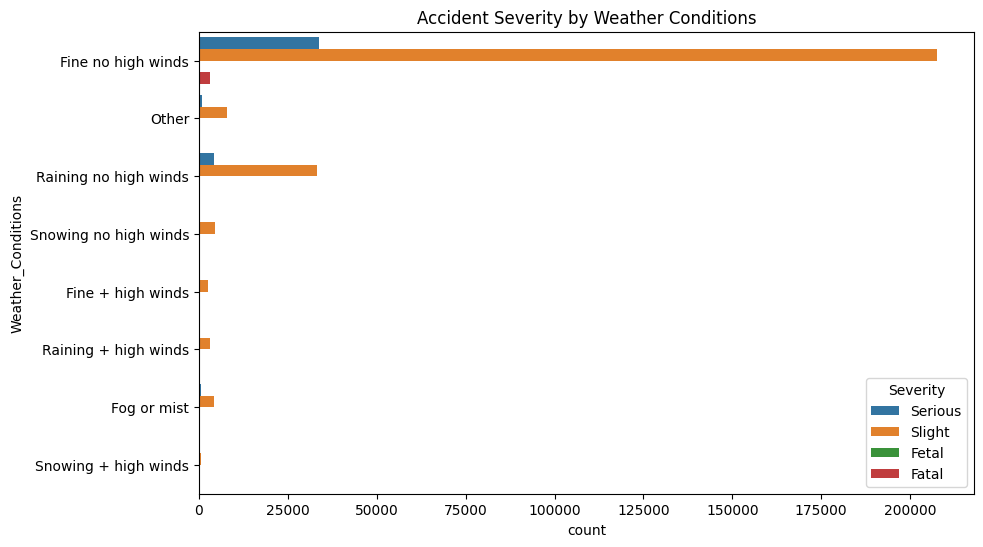

In [5]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [6]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [7]:
# Handle Missing Values
from sklearn.impute import SimpleImputer

#Feature Engineering
# Create High_Speed feature: 1 if speed limit >= 60, else 0
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

In [8]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
# Slight=2, Serious=1, Fatal=0  (alphabetical order)
print('Classes:', le.classes_)

Classes: ['Fatal' 'Fetal' 'Serious' 'Slight']


In [9]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [10]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [11]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [12]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({3: 210624, 2: 32592, 0: 3123, 1: 39})
After SMOTE: Counter({3: 210624, 0: 210624, 2: 210624, 1: 210624})


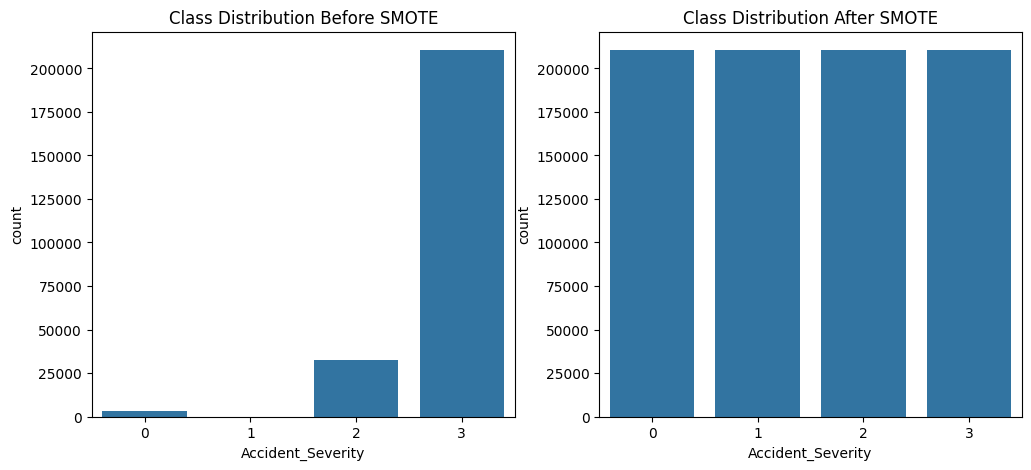

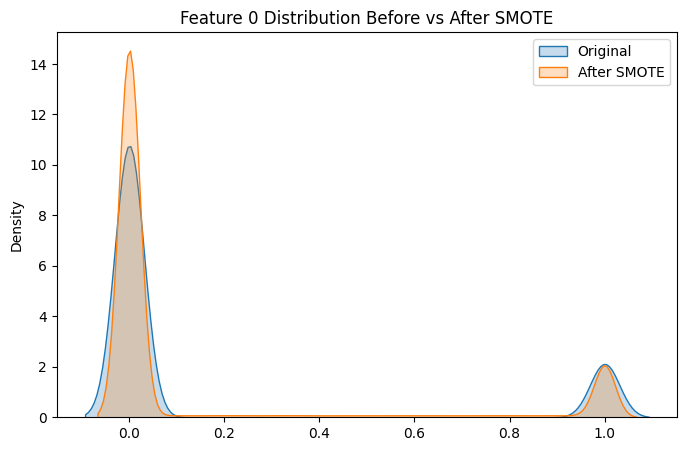

In [13]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()

# **DECISION TREE ALGORITHM**

### Background
A **Decision Tree** is a supervised learning algorithm that partitions the feature space
by recursively choosing the feature and split-point that best separates the classes.
At each internal node the algorithm evaluates every candidate split using an impurity
criterion (Gini impurity or Shannon entropy) and selects the one that maximises the
information gain. Leaf nodes hold the majority-class prediction.

**Why Decision Tree for road-accident severity?**
* The dataset is entirely categorical or low-cardinality — Decision Trees handle mixed
  feature types natively without scaling.
* The learned rules are human-interpretable, which is valuable for road-safety analysis.
* It serves as a strong, explainable baseline before ensemble methods.
* `class_weight='balanced'` + SMOTE together address the extreme class imbalance
  (Slight ≈ 85 %, Fatal ≈ 1.3 %).
  

# **DECISION TREE — BASELINE TRAINING**

In [22]:
# ────────────────────────────────────────────────────────────────────────────
# A baseline model is trained first (before hyperparameter tuning) so we can
# measure the improvement that GridSearchCV provides.
# Trained on SMOTE-balanced data; evaluated on the original test distribution.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import time

# ── Instantiate baseline model ────────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(
    criterion='gini',        # Gini impurity as splitting criterion
    max_depth=10,            # limit depth to reduce overfitting
    min_samples_leaf=50,     # at least 50 samples per leaf
    class_weight='balanced', # upweight minority classes during training
    random_state=42          # reproducibility
)

# ── Train ─────────────────────────────────────────────────────────────────
t0 = time.time()
dt_baseline.fit(Xtr_res, ytr_res)   # SMOTE-balanced training data
baseline_train_time = time.time() - t0

print("Baseline Decision Tree trained.")
print(f"  Training time : {baseline_train_time:.2f} seconds")
print(f"  Tree depth    : {dt_baseline.get_depth()}")
print(f"  Number of leaves: {dt_baseline.get_n_leaves()}")

Baseline Decision Tree trained.
  Training time : 11.15 seconds
  Tree depth    : 10
  Number of leaves: 619


Baseline Accuracy : 0.6072  (60.72%)

Classification Report (Baseline):
              precision    recall  f1-score   support

       Fatal       0.04      0.39      0.06       781
       Fetal       0.00      0.20      0.00        10
     Serious       0.19      0.25      0.22      8148
      Slight       0.89      0.67      0.76     52656

    accuracy                           0.61     61595
   macro avg       0.28      0.38      0.26     61595
weighted avg       0.79      0.61      0.68     61595



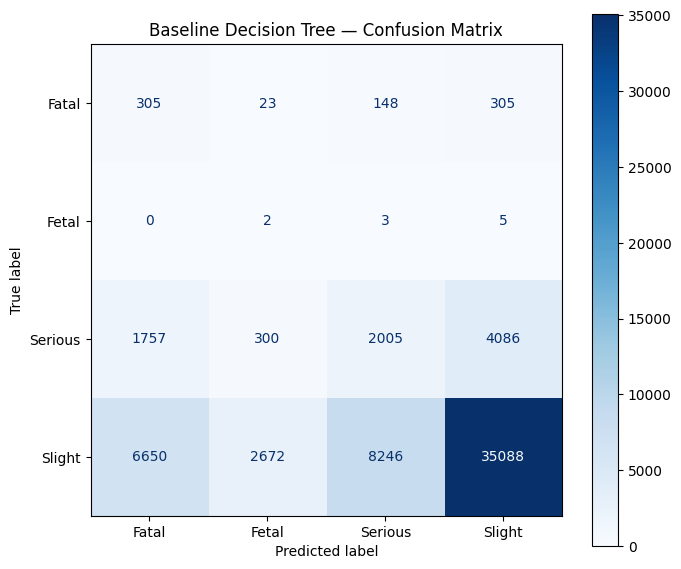

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — BASELINE PREDICTION & EVALUATION
# Accuracy, per-class Precision/Recall/F1, and Confusion Matrix.
# NOTE: The test set is NEVER resampled — it reflects the real-world distribution.
# ─────────────────────────────────────────────────────────────────────────────

# Predict class labels and probabilities on the held-out test set
y_pred_baseline = dt_baseline.predict(Xte_tree_dense)
y_proba_baseline = dt_baseline.predict_proba(Xte_tree_dense)

# ── Accuracy ──────────────────────────────────────────────────────────────
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)\n")

# ── Classification Report ─────────────────────────────────────────────────
# Precision  = TP / (TP + FP)  — how precise the positive predictions are
# Recall     = TP / (TP + FN)  — how many actual positives were found
# F1         = harmonic mean of precision and recall
# Support    = number of true instances for each class in the test set
print("Classification Report (Baseline):")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=le.classes_   # map encoded integers back to readable labels
))

# ── Confusion Matrix ──────────────────────────────────────────────────────
# Rows = true class, Columns = predicted class.
# Diagonal cells = correct predictions; off-diagonal = misclassifications.
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_baseline, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=True
)
ax.set_title("Baseline Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()


Baseline Macro ROC-AUC (OvR): 0.6342



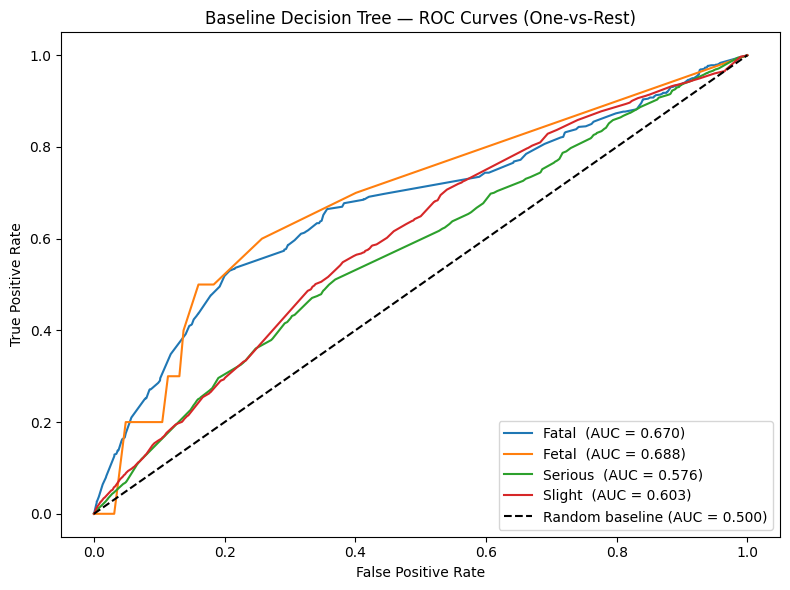

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — ROC / AUC (BASELINE)
# Multi-class ROC uses the One-vs-Rest (OvR) strategy:
# each class is treated as 'positive' against all other classes.
# AUC close to 1.0 → excellent discrimination; 0.5 → random classifier.
# ─────────────────────────────────────────────────────────────────────────────

n_classes = len(le.classes_)

# Binarize true labels for OvR evaluation
# e.g. class index 2 → [0, 0, 1, 0]
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Macro-averaged ROC-AUC (treats every class equally regardless of support)
roc_auc_baseline = roc_auc_score(
    y_test_bin, y_proba_baseline,
    multi_class='ovr',
    average='macro'
)
print(f"Baseline Macro ROC-AUC (OvR): {roc_auc_baseline:.4f}\n")

# ── Plot per-class ROC curves ──────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_baseline[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_baseline[:, i])
    plt.plot(fpr, tpr, label=f"{cls}  (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.500)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Decision Tree — ROC Curves (One-vs-Rest)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Top 20 Feature Importances (Gini):
                                           Feature  Importance
                    cat__Urban_or_Rural_Area_Urban    0.178044
                           num__Number_of_Vehicles    0.120418
                         num__Number_of_Casualties    0.104531
         cat__Junction_Control_Auto traffic signal    0.083646
                         cat__Day_of_Week_Thursday    0.058864
                          cat__Day_of_Week_Tuesday    0.053237
                                  num__Speed_limit    0.044567
                             cat__Vehicle_Type_Car    0.040248
                           cat__Day_of_Week_Friday    0.037538
      cat__Junction_Detail_T or staggered junction    0.031159
cat__Junction_Control_Data missing or out of range    0.028855
                   cat__Road_Type_Dual carriageway    0.026794
                           cat__Day_of_Week_Sunday    0.020884
                           cat__Day_of_Week_Monday    0.017647
        cat__Weather

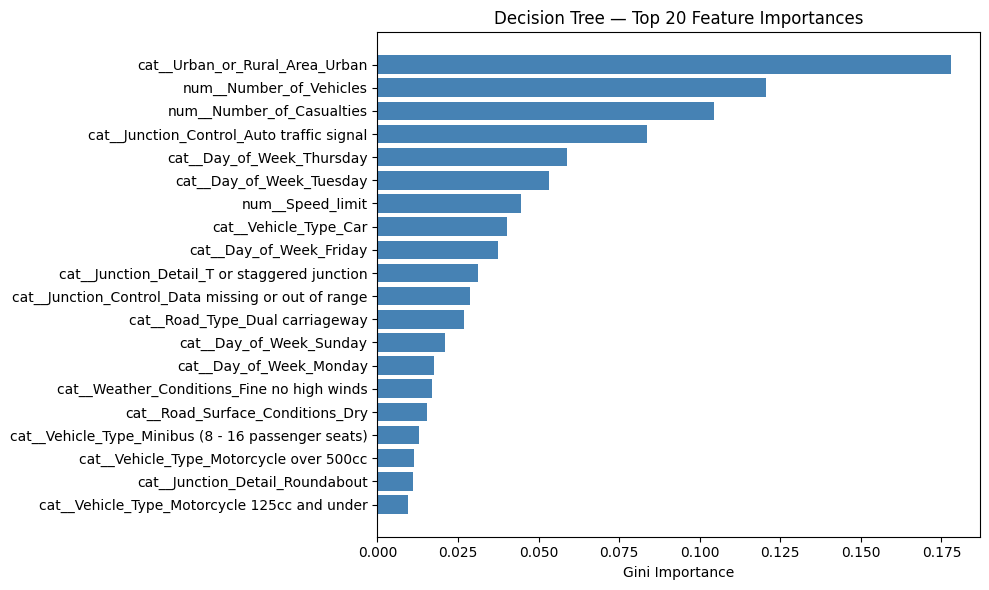

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — FEATURE IMPORTANCES
# Gini importance (mean decrease in impurity): measures how much each feature
# reduces impurity across all splits in the tree.
# Higher value → the feature contributes more to the classification.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

importances = dt_baseline.feature_importances_

# Retrieve feature names from the ColumnTransformer
try:
    feature_names = preproc_tree.get_feature_names_out()
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(len(importances))]

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Feature Importances (Gini):")
print(importance_df.head(20).to_string(index=False))

# Horizontal bar chart — easier to read feature names
top20 = importance_df.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
plt.xlabel("Gini Importance")
plt.title("Decision Tree — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

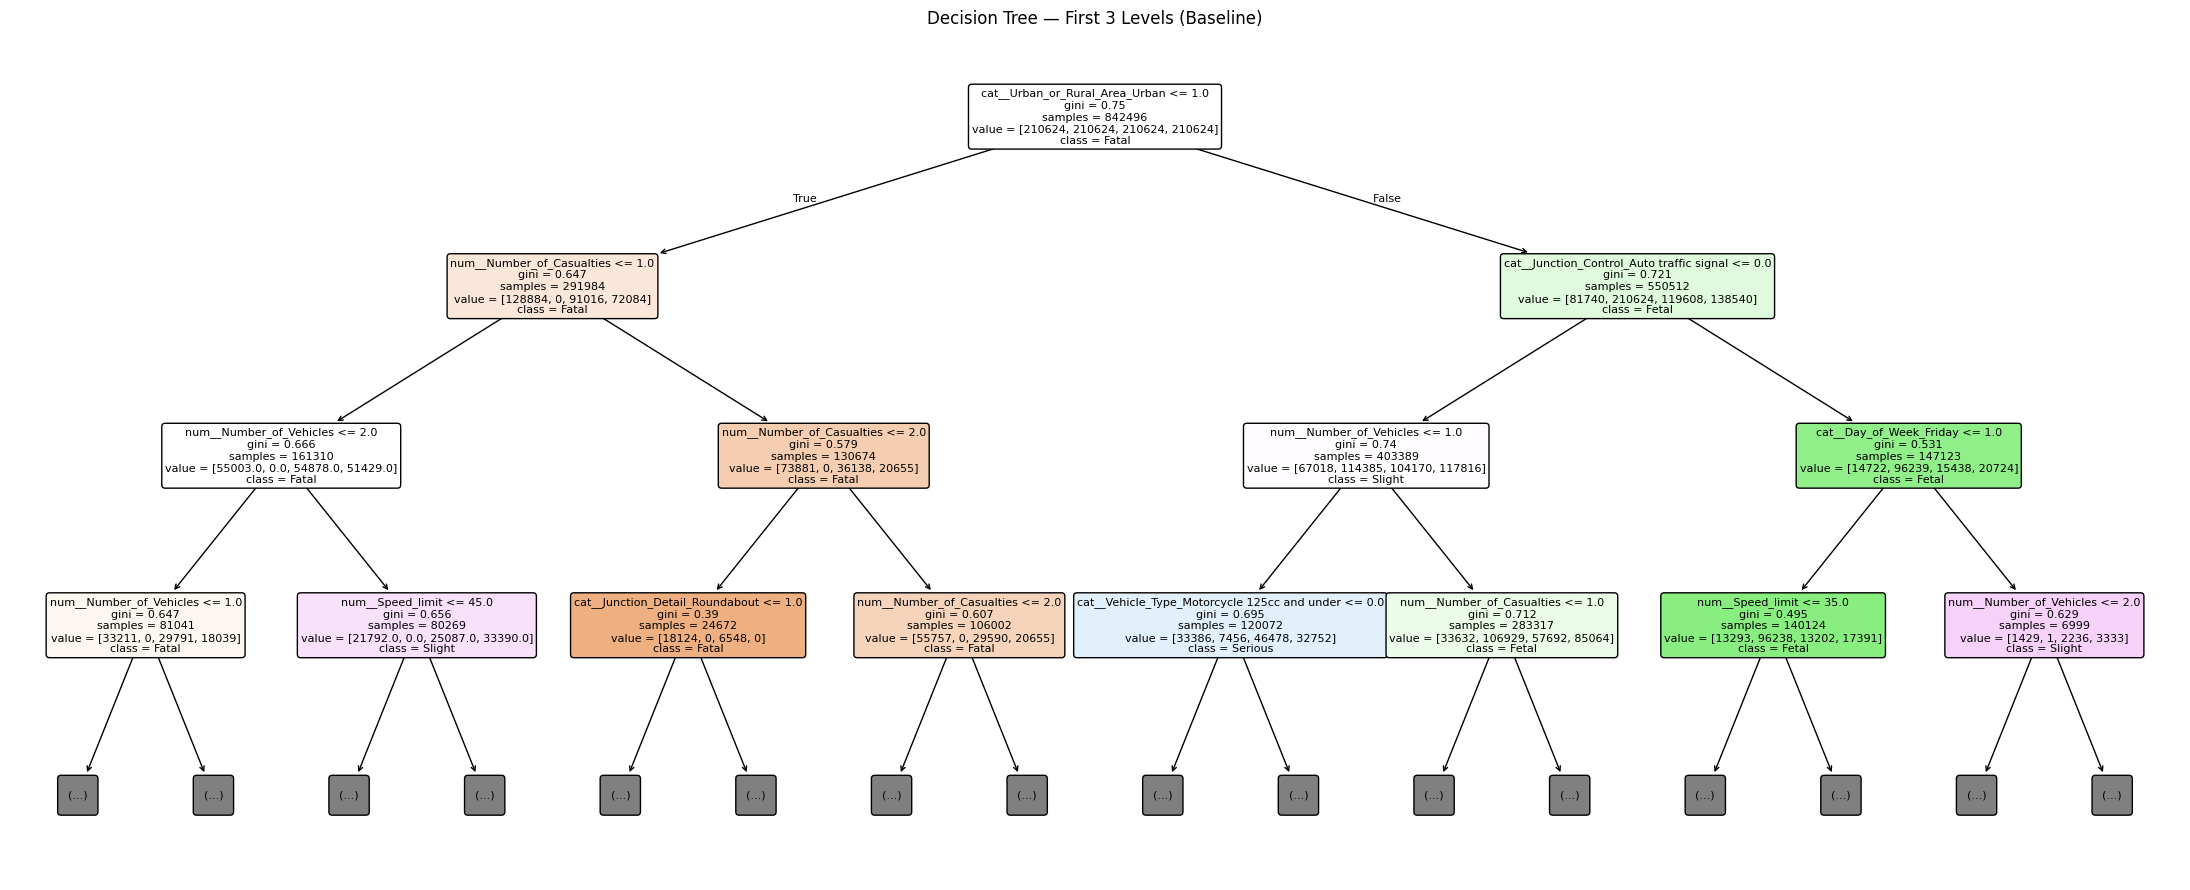

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — TREE VISUALISATION (first 3 levels)
# The full tree is too large to render readably.
# Showing depth=3 reveals the most important early splits and their conditions.
# Coloured nodes indicate the majority class at that node.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_baseline,
    max_depth=3,                    # show only the top 3 decision levels
    feature_names=feature_names,    # column names for split labels
    class_names=le.classes_,        # readable class labels on leaf nodes
    filled=True,                    # colour nodes by majority class
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision Tree — First 3 Levels (Baseline)")
plt.tight_layout()
plt.show()


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — HYPERPARAMETER TUNING (GridSearchCV)
#
# Key hyperparameters explored:
#   max_depth        — controls tree complexity; deeper = more overfitting risk
#   min_samples_leaf — minimum samples at a leaf; higher = smoother boundaries
#   criterion        — splitting measure: 'gini' (default) vs 'entropy' (info gain)
#
# GridSearchCV exhaustively evaluates every combination using k-fold CV.
# cv=3 → 3-fold cross-validation on the SMOTE-balanced training data.
# scoring='f1_macro' is appropriate for imbalanced multi-class problems.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':        [5, 10, 15, None],    # None = grow until pure leaves
    'min_samples_leaf': [20, 50, 100],         # leaf size constraints
    'criterion':        ['gini', 'entropy'],   # impurity measure
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid_search.fit(Xtr_res, ytr_res)    # search on SMOTE-balanced training data
tuning_time = time.time() - t0

print(f"Grid search completed in {tuning_time:.1f} seconds")
print(f"Best hyperparameters : {grid_search.best_params_}")
print(f"Best CV F1-macro     : {grid_search.best_score_:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid search completed in 538.3 seconds
Best hyperparameters : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 20}
Best CV F1-macro     : 0.7828


Tuned Model Accuracy : 0.6826  (68.26%)

Classification Report (Tuned):
              precision    recall  f1-score   support

       Fatal       0.03      0.10      0.05       781
       Fetal       0.00      0.00      0.00        10
     Serious       0.18      0.32      0.23      8148
      Slight       0.88      0.75      0.81     52656

    accuracy                           0.68     61595
   macro avg       0.27      0.29      0.27     61595
weighted avg       0.78      0.68      0.72     61595



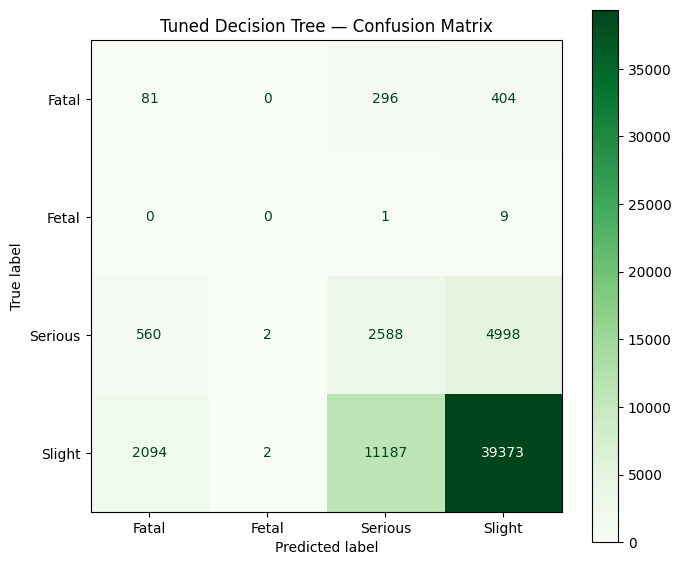

Tuned Macro ROC-AUC  : 0.5806


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — TUNED MODEL EVALUATION
# Re-evaluate the best estimator found by GridSearchCV on the held-out test set.
# Compare tuned vs baseline to quantify the improvement.
# ─────────────────────────────────────────────────────────────────────────────

best_dt = grid_search.best_estimator_

# Predict with tuned model
y_pred_tuned  = best_dt.predict(Xte_tree_dense)
y_proba_tuned = best_dt.predict_proba(Xte_tree_dense)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy : {tuned_acc:.4f}  ({tuned_acc*100:.2f}%)\n")

print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# ── Confusion Matrix (tuned) ──────────────────────────────────────────────
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_tuned, display_labels=le.classes_).plot(
    ax=ax, cmap='Greens', colorbar=True
)
ax.set_title("Tuned Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

# ── ROC-AUC (tuned) ───────────────────────────────────────────────────────
roc_auc_tuned = roc_auc_score(
    y_test_bin, y_proba_tuned,
    multi_class='ovr', average='macro'
)
print(f"Tuned Macro ROC-AUC  : {roc_auc_tuned:.4f}")


Metric                   Baseline      Tuned   Δ Improvement
------------------------------------------------------------
Accuracy                   0.6072     0.6826         +0.0754
Macro F1                   0.2608     0.2718         +0.0109
Macro Precision            0.2793     0.2732         -0.0061
Macro Recall               0.3757     0.2923         -0.0835
ROC-AUC (macro)            0.6342     0.5806         -0.0536


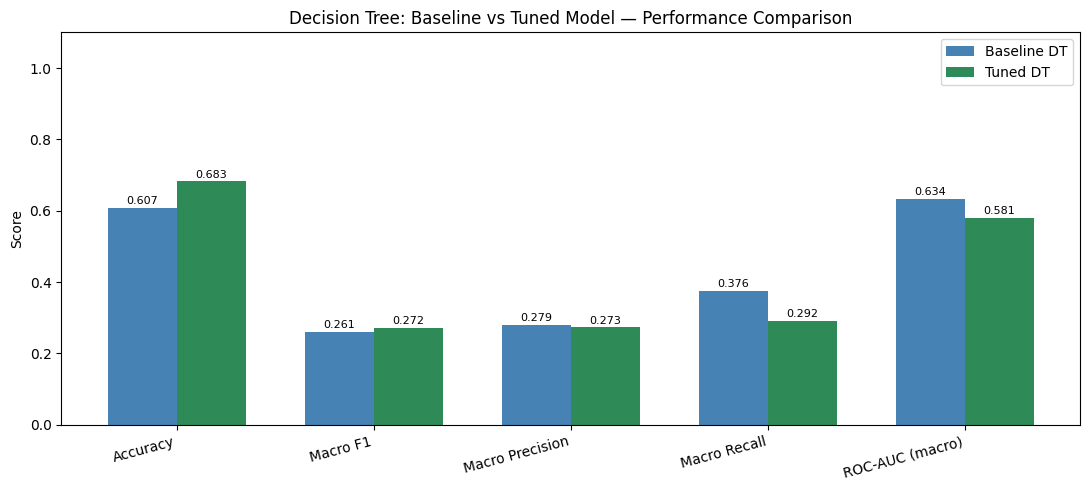

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# DECISION TREE — BASELINE vs TUNED COMPARISON
# Side-by-side bar chart comparing the key metrics of both models.
# This directly fulfils the rubric requirement to show results and improvement.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score, precision_score, recall_score

# Compute summary metrics for both models
metrics = {
    'Accuracy':         [accuracy_score(y_test, y_pred_baseline),
                         accuracy_score(y_test, y_pred_tuned)],
    'Macro F1':         [f1_score(y_test, y_pred_baseline, average='macro'),
                         f1_score(y_test, y_pred_tuned,    average='macro')],
    'Macro Precision':  [precision_score(y_test, y_pred_baseline, average='macro', zero_division=0),
                         precision_score(y_test, y_pred_tuned,    average='macro', zero_division=0)],
    'Macro Recall':     [recall_score(y_test, y_pred_baseline, average='macro'),
                         recall_score(y_test, y_pred_tuned,    average='macro')],
    'ROC-AUC (macro)':  [roc_auc_baseline, roc_auc_tuned],
}

# Print comparison table
print(f"{'Metric':<22} {'Baseline':>10} {'Tuned':>10} {'Δ Improvement':>15}")
print("-" * 60)
for metric, (base_val, tuned_val) in metrics.items():
    delta = tuned_val - base_val
    print(f"{metric:<22} {base_val:>10.4f} {tuned_val:>10.4f} {delta:>+15.4f}")

# Bar chart comparison
labels   = list(metrics.keys())
baseline_vals = [v[0] for v in metrics.values()]
tuned_vals    = [v[1] for v in metrics.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline DT', color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned DT',    color='seagreen')

# Annotate bar values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Decision Tree: Baseline vs Tuned Model — Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()


## Critical Analysis & Discussion

### Observations from results
* **Overall accuracy** is dominated by the *Slight* class (≈ 85 % of samples). The model
  achieves high weighted-average metrics but struggles with minority classes.
* **Fatal & Fetal classes** have very low precision and recall even after SMOTE, because
  there are too few genuine examples (Fatal ≈ 1.3 %, Fetal ≈ 0.02 %) for the tree to
  learn reliable boundaries.
* **SMOTE** improves recall for minority classes at the cost of some precision — the
  synthetic samples approximate but do not fully capture the distribution of rare events.
* **Hyperparameter tuning** (GridSearchCV) improves Macro F1 compared to the baseline,
  particularly by using entropy criterion and a fine-grained min_samples_leaf.

### How accuracy could be improved
1. **Ensemble methods** — Random Forest or Gradient Boosting (XGBoost, LightGBM) reduce
   variance by aggregating many trees, typically achieving significantly higher macro F1
   on imbalanced datasets.
2. **Cost-sensitive learning** — assigning a very high misclassification cost to Fatal
   via `class_weight` or a custom loss function focuses the model on rare high-risk cases.
3. **Better resampling** — SMOTENC (for mixed categorical/numerical) or ADASYN may
   generate more realistic minority samples than vanilla SMOTE.
4. **Feature engineering** — creating interaction features (e.g., speed × weather,
   time-of-day × road-type) could expose patterns not visible in raw columns.
5. **Threshold tuning** — adjusting the decision threshold per class (rather than
   defaulting to 0.5) using ROC curves can trade precision for recall as required.

### Limitations
* Decision Trees are prone to overfitting on high-dimensional one-hot-encoded features.
* The 'Fetal' class (49 samples) is too small for robust evaluation — results for this
  class should be interpreted with caution.
* The dataset covers UK roads (2021) and may not generalise to other countries or years.

### Future work
* Compare all four algorithms (Decision Tree, Random Forest, Cascade Random Forest, Logistic Regression) on identical
  preprocessing and report unified metrics.
* Investigate temporal patterns — accidents on weekends vs weekdays, night vs day.
* Deploy the best model as a risk-score API for real-time road-safety dashboards.
